In [551]:
# Importamos las librerías necesarias

import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

import seaborn as sns
import matplotlib.pyplot as plt

Fase 1: Exploración y Limpieza
1. Exploración Inicial

In [552]:
df_clientes_vuelos = pd.read_csv("data/Customer_Flight_Activity.csv")
df_clientes_perfil = pd.read_csv("data/Customer_Loyalty_History.csv")

In [553]:
# Funcion para exploración básica

def exploracion_basica(df, nombre="Dataframe"):
    print(f"\n Exploración de: {nombre}")
    print("\n .head, datos primeros")
    display(df.head(2))
    print("=" * 100)
    print("\n .tail, datos finales")
    display(df.tail(2))
    print("=" * 100)
    print("\n .sample,datos aleatorios")
    display(df.sample(2))
    print("=" * 100)
    print("\n Información:")
    print(df.info())
    print("=" * 100)
    print(f"El dataframe tiene {df.shape[0]} filas y {df.shape[1]} columnas")

In [554]:
exploracion_basica(df_clientes_vuelos, "Clientes Vuelos")
exploracion_basica(df_clientes_perfil, "Clientes Perfil")


 Exploración de: Clientes Vuelos

 .head, datos primeros


,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,100018,2017,1,3,0,3,1521,152,0,0
1,100102,2017,1,10,4,14,2030,203,0,0



 .tail, datos finales


,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
403758,999982,2018,12,0,0,0,0,0,0,0
403759,999986,2018,12,0,0,0,0,0,0,0



 .sample,datos aleatorios


...


 .tail, datos finales


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
16735,906428,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,-57297.0,Married,Star,10018.66,2018 Promotion,2018,4,NaN,NaN
16736,652627,Canada,Manitoba,Winnipeg,R2C 0M5,Female,Bachelor,75049.0,Married,Star,83325.38,Standard,2015,12,2016.0,8.0



 .sample,datos aleatorios


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
7730,379038,Canada,Manitoba,Winnipeg,R2C 0M5,Male,Doctor,125825.0,Married,Nova,7609.09,Standard,2018,7,NaN,NaN
5180,237018,Canada,Quebec,Montreal,H2Y 2W2,Male,Bachelor,58372.0,Divorced,Nova,3549.02,Standard,2015,3,NaN,NaN



 Información:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loyalty Number      16737 non-null  int64  
 1   Country             16737 non-null  object 
 2   Province            16737 non-null  object 
 3   City                16737 non-null  object 
 4   Postal Code         16737 non-null  object 
 5   Gender              16737 non-null  object 
 6   Education           16737 non-null  object 
 7   Salary              12499 non-null  float64
 8   Marital Status      16737 non-null  object 
 9   Loyalty Card        16737 non-null  object 
 10  CLV                 16737 non-null  float64
 11  Enrollment Type     16737 non-null  object 
 12  Enrollment Year     16737 non-null  int64  
 13  Enrollment Month    16737 non-null  int64  
 14  Cancellation Year   2067 non-null   float64
 15  Cancellation Month  2067 non-null   fl

##  Conclusiones del análisis de datos

Según los datos obtenidos, podemos extraer las siguientes conclusiones:

- Las columnas de ambos archivos presentan una estructura homogénea en cuanto a nomenclatura, siguiendo el formato de primera letra en mayúscula y el resto en minúsculas.
- Pero vamos a unir las nombres que estan separados por un espacio y unirlos por un guion bajo. ✅

- Se ha detectado que en la columna **Enrollment Type** existen valores que combinan el año y la categoría de forma repetida, por lo que sería necesario realizar una limpieza o transformación de estos datos en el DataFrame de **df_clientes_perfil**. ✅

- El DataFrame **df_clientes_vuelos** contiene un mayor número de filas que **df_clientes_perfil**, lo cual es coherente, ya que un mismo cliente puede realizar múltiples vuelos.
La Relación entre tablas es 1:N y se conectan por Loyalty Number.

###  df_clientes_vuelos

- No se han identificado valores nulos.

###  df_clientes_perfil

- Se han identificado valores nulos en:
  - **Salary**: 4.238 nulos  
  - **Cancellation Year**: 14.670 nulos  
  - **Cancellation Month**: 14.670 nulos
  - En Cancellation Year y Month hay muchos nulos, muchos clientes que no han cancelado.

- Sería recomendable cambiar el tipo de dato de las columnas:
  - **Cancellation Year** → entero  
  - **Cancellation Month** → entero 
  - Ya que no tiene sentido tenerlos como float siendo enteros el año y mes. Tener en cuenta que tiene nulos a la hora de pasarlo a entero, ya que panda los convierte a float.
  - Los valores nulos en Cancellation Year y Cancellation Month probablemente indican que el cliente no ha cancelado. Podemos dejarlos en nulo y con la función Int64 pasar el tipo de dato a entero y añadir una columna de Cancelled que nos indique si ha cancelado o no con algun valor ejemplo 0/1 o si/no.
  - Pero tambien tenemos que fijarnos en que los dos valores de las columnas de year y month esten completas para que nos identifique si hay algun error en esos datos y se cumpla la condición. ✅

- Me he dado cuenta que en Salary tambien aparece datos en negativo. Un salario no puede ser negativo, por lo cual es un dato erroneo. No sabemos el valor real, al igual que los nulos.
Vamos a converir estos datos en negativo a nulos y luego vemos que hacemos con ellos.✅



2. Limpieza de Datos

In [555]:
df_clientes_vuelos.columns

Index(['loyalty_number', 'year', 'month', 'flights_booked',
       'flights_with_companions', 'total_flights', 'distance',
       'points_accumulated', 'points_redeemed', 'dollar_cost_points_redeemed'],
      dtype='object')

In [556]:
def limpiar_columnas(df):
    nuevas_cols = {
        col: col.strip().lower().replace(" ", "_")
        for col in df.columns
    }
    df.rename(columns=nuevas_cols, inplace=True)
    return df

In [557]:
df_clientes_vuelos = limpiar_columnas(df_clientes_vuelos)

df_clientes_vuelos

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,100018,2017,1,3,0,3,1521,152,0,0
1,100102,2017,1,10,4,14,2030,203,0,0
2,100140,2017,1,6,0,6,1200,120,0,0
3,100214,2017,1,0,0,0,0,0,0,0
4,100272,2017,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
403755,999902,2018,12,0,0,0,0,0,0,0
403756,999911,2018,12,0,0,0,0,0,0,0
403757,999940,2018,12,3,0,3,1233,123,0,0
403758,999982,2018,12,0,0,0,0,0,0,0


In [558]:
df_clientes_perfil = limpiar_columnas(df_clientes_perfil)

df_clientes_perfil

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16732,823768,Canada,British Columbia,Vancouver,V6E 3Z3,Female,College,NaN,Married,Star,61850.19,Standard,2012,12,NaN,NaN
16733,680886,Canada,Saskatchewan,Regina,S1J 3C5,Female,Bachelor,89210.0,Married,Star,67907.27,Standard,2014,9,NaN,NaN
16734,776187,Canada,British Columbia,Vancouver,V5R 1W3,Male,College,NaN,Single,Star,74228.52,Standard,2014,3,NaN,NaN
16735,906428,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,-57297.0,Married,Star,10018.66,2018 Promotion,2018,4,NaN,NaN


In [559]:
# Ver valores antes de limpiar
df_clientes_perfil["enrollment_type"].value_counts()

enrollment_type
Standard          15766
2018 Promotion      971
Name: count, dtype: int64

In [560]:
# Limpiar enrollment_type dejando solo la categoría
df_clientes_perfil["enrollment_type"] = df_clientes_perfil["enrollment_type"].str.replace(r"^\d{4}\s*", "", regex=True).str.strip()

In [561]:
# Ver valores despues de limpiar
df_clientes_perfil["enrollment_type"].value_counts()

enrollment_type
Standard     15766
Promotion      971
Name: count, dtype: int64

In [562]:
df_clientes_perfil[
    df_clientes_perfil["cancellation_year"].notnull() &
    df_clientes_perfil["cancellation_month"].isnull()
]

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month


In [563]:
df_clientes_perfil[
    df_clientes_perfil["cancellation_year"].isnull() &
    df_clientes_perfil["cancellation_month"].notnull()
]

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month


In [564]:
df_clientes_perfil["cancelled"] = (
    df_clientes_perfil["cancellation_year"].notnull() |
    df_clientes_perfil["cancellation_month"].notnull()
).astype(int)

In [565]:
df_clientes_perfil.head(5)

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,cancelled
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN,0
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN,0
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0,1
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN,0
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN,0


In [566]:
def convertir_Int64(df, columnas):
    for col in columnas:
        df[col] = df[col].astype("Int64")
    return df

In [567]:
df_clientes_perfil = convertir_Int64(df_clientes_perfil, ["cancellation_year", "cancellation_month"])

In [568]:
df_clientes_perfil.dtypes

loyalty_number          int64
country                object
province               object
city                   object
postal_code            object
gender                 object
education              object
salary                float64
marital_status         object
loyalty_card           object
clv                   float64
enrollment_type        object
enrollment_year         int64
enrollment_month        int64
cancellation_year       Int64
cancellation_month      Int64
cancelled               int64
dtype: object

In [569]:
df_clientes_perfil.loc[df_clientes_perfil["salary"] < 0, "salary"] = np.nan

In [570]:
df_clientes_perfil.tail(2)

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,cancelled
16735,906428,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,NaN,Married,Star,10018.66,Promotion,2018,4,<NA>,<NA>,0
16736,652627,Canada,Manitoba,Winnipeg,R2C 0M5,Female,Bachelor,75049.0,Married,Star,83325.38,Standard,2015,12,2016,8,1


Fase 2 : Análisis Estadistico

1. Análisis de variables numéricas:
    1. Estadísticas descriptivas (media, mediana, moda, desviación estándar, etc.) de las variables
    numéricas relevantes.
    2. Identificación de valores atípicos en las variables numéricas.
    3. Análisis de correlación entre variables numéricas.

2. Análisis de variables categóricas:
    1. Distribución de frecuencias de las variables categóricas relevantes.

In [571]:
def analisis_estadistico(df):
    print("🔹 NUMÉRICAS")
    display(df.describe(include="number").T)

    print("\n🔹 CATEGÓRICAS")
    columnas_object = df.select_dtypes(include="object")
    if columnas_object.shape[1] > 0:
        display(columnas_object.describe().T)
    else:
        print("No hay columnas categóricas en este DataFrame.")

    return df


In [572]:
analisis_estadistico(df_clientes_vuelos)

🔹 NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max
loyalty_number,403760.0,549875.383713,258961.514684,100018.0,326699.0,550598.0,772152.0,999986.0
year,403760.0,2017.500352,0.500000,2017.0,2017.0,2018.0,2018.0,2018.0
month,403760.0,6.501335,3.451982,1.0,4.0,7.0,10.0,12.0
flights_booked,403760.0,4.134050,5.230064,0.0,0.0,1.0,8.0,21.0
flights_with_companions,403760.0,1.036569,2.080472,0.0,0.0,0.0,1.0,11.0
total_flights,403760.0,5.170619,6.526858,0.0,0.0,1.0,10.0,32.0
distance,403760.0,1214.460979,1434.098521,0.0,0.0,525.0,2342.0,6293.0
points_accumulated,403760.0,124.263756,146.696401,0.0,0.0,53.0,240.0,676.0
points_redeemed,403760.0,30.838587,125.758002,0.0,0.0,0.0,0.0,876.0
dollar_cost_points_redeemed,403760.0,2.495973,10.172033,0.0,0.0,0.0,0.0,71.0



🔹 CATEGÓRICAS
No hay columnas categóricas en este DataFrame.


,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,100018,2017,1,3,0,3,1521,152,0,0
1,100102,2017,1,10,4,14,2030,203,0,0
2,100140,2017,1,6,0,6,1200,120,0,0
3,100214,2017,1,0,0,0,0,0,0,0
4,100272,2017,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
403755,999902,2018,12,0,0,0,0,0,0,0
403756,999911,2018,12,0,0,0,0,0,0,0
403757,999940,2018,12,3,0,3,1233,123,0,0
403758,999982,2018,12,0,0,0,0,0,0,0


## Análisis de variables numéricas (df_clientes_vuelos)

- Observamos que tenemos 405.624 registros en total.

- Como ya sabiamos no aparecen nulos.

- Variables como **flights_booked**, **points_redeemed** y **dollar_cost_points_redeemed** presentan una alta concentración de valores 0, lo que sugiere que una gran parte de los clientes tiene baja o nula actividad.

- La variable **points_accumulated** tiene valores decimales, tendremos que revisar el tipo de dato.

- Las variables **loyarty_number**, **year**, **month**, son variables que no nos dicen nada, identificadores numericos.

- En general, se identifica una distribución sesgada en varias variables, con presencia de valores extremos que pueden influir en la media.

## Análisis de variables categoricas

- Nos da error en el DataFrame de pd_clientes_vuelos, porque el tipo de dato es numérico y no tiene ningun dato categórico.
En este DataFrame no se podria analizar.


## Análisis de variables numéricas (df_clientes_vuelos)

- Observamos que tenemos 405.624 registros en total.

- Se han detectado valores nulos en el pd_clientes_perfil.

- Variables como **flights_booked**, **points_redeemed** y **dollar_cost_points_redeemed** tienen muchos valores 0, lo que indica que muchos clientes tienen poca o ninguna actividad.

- La variable **points_accumulated** tiene valores decimales, por lo que sería conveniente revisar si debería ser un número entero.

- Las variables **loyalty_number**, **year** y **month** no aportan información relevante para el análisis.

- En general, los datos presentan bastante diferencia entre unos clientes y otros, con algunos valores muy altos que pueden afectar a la media.

## Análisis de variables categóricas

- No se han podido analizar variables categóricas en este DataFrame, ya que todas las columnas son numéricas y no hay variables de tipo texto.

In [573]:
analisis_estadistico(df_clientes_perfil)

🔹 NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max
loyalty_number,16737.0,549735.880445,258912.132453,100018.0,326603.0,550434.0,772019.0,999986.0
salary,12479.0,79429.572642,34727.560404,15609.0,59265.0,73510.0,88600.5,407228.0
clv,16737.0,7988.896536,6860.98228,1898.01,3980.84,5780.18,8940.58,83325.38
enrollment_year,16737.0,2015.253211,1.979111,2012.0,2014.0,2015.0,2017.0,2018.0
enrollment_month,16737.0,6.669116,3.398958,1.0,4.0,7.0,10.0,12.0
cancellation_year,2067.0,2016.503145,1.380743,2013.0,2016.0,2017.0,2018.0,2018.0
cancellation_month,2067.0,6.962748,3.455297,1.0,4.0,7.0,10.0,12.0
cancelled,16737.0,0.123499,0.329019,0.0,0.0,0.0,0.0,1.0



🔹 CATEGÓRICAS


,count,unique,top,freq
country,16737,1,Canada,16737
province,16737,11,Ontario,5404
city,16737,29,Toronto,3351
postal_code,16737,55,V6E 3D9,911
gender,16737,2,Female,8410
education,16737,5,Bachelor,10475
marital_status,16737,3,Married,9735
loyalty_card,16737,3,Star,7637
enrollment_type,16737,2,Standard,15766


,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,cancelled
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,<NA>,<NA>,0
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,<NA>,<NA>,0
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018,1,1
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,<NA>,<NA>,0
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,<NA>,<NA>,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16732,823768,Canada,British Columbia,Vancouver,V6E 3Z3,Female,College,NaN,Married,Star,61850.19,Standard,2012,12,<NA>,<NA>,0
16733,680886,Canada,Saskatchewan,Regina,S1J 3C5,Female,Bachelor,89210.0,Married,Star,67907.27,Standard,2014,9,<NA>,<NA>,0
16734,776187,Canada,British Columbia,Vancouver,V5R 1W3,Male,College,NaN,Single,Star,74228.52,Standard,2014,3,<NA>,<NA>,0
16735,906428,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,NaN,Married,Star,10018.66,Promotion,2018,4,<NA>,<NA>,0


## Análisis de variables numéricas (df_clientes_perfil)

- Observamos que tenemos 405.624 registros en total.

- La variable **salary** tiene valores nulos y bastante diferencia entre unos clientes y otros. Además, hay algunos salarios muy altos que pueden ser valores atípicos.

- La variable **clv (customer_lifetime_value)** también varía mucho, lo que indica que hay clientes que generan mucho más valor que otros.

- Las columnas **cancellation_year** y **cancellation_month** solo tienen datos en los clientes que han cancelado. Cuando están vacías (NaN), significa que el cliente sigue activo.

- La variable **cancelled** muestra que aproximadamente el **12,3% de los clientes ha cancelado**, mientras que el **87,7% sigue activo**.

- Las variables **enrollment_year** y **enrollment_month** indican que la mayoría de los clientes se registraron en los últimos años.

## Análisis de variables categóricas (df_clientes_perfil)

- La variable **country** solo tiene un valor (Canada), por lo que no aporta información útil.

- La variable **province** tiene 11 valores distintos, siendo **Ontario** la más común.

- La variable **city** incluye 29 ciudades diferentes, destacando **Toronto** como la más frecuente.

- La variable **postal_code** tiene muchos valores distintos, lo que indica variedad en la ubicación de los clientes.

- La variable **gender** tiene dos categorías, con una mayoría de mujeres.

- La variable **education** tiene 5 niveles, siendo **Bachelor** el más habitual.

- La variable **marital_status** tiene 3 categorías, predominando los clientes casados.

- La variable **loyalty_card** tiene 3 tipos, siendo **Star** el más común.

- La variable **enrollment_type** tiene 2 categorías, donde **Standard** es la más frecuente.

In [574]:
print(df_clientes_vuelos.duplicated().sum())
print(df_clientes_perfil.duplicated().sum())

0
0


In [575]:
mascara_duplicados_clientes_vuelos = df_clientes_vuelos.duplicated(keep=False)

df_clientes_vuelos[mascara_duplicados_clientes_vuelos].sort_values(by="loyalty_number")

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed


In [576]:
df_clientes_vuelos.drop_duplicates(inplace=True)
print(df_clientes_vuelos.duplicated().sum())

0


- Miramos si los DataFrame tienen duplicados y los eliminamos.
Aqui solo el df_clientes_vuelos tenia duplicados.

In [577]:
print(df_clientes_vuelos.isnull().sum())
print("=" * 100)
print(df_clientes_vuelos.select_dtypes(include="number").isnull().sum())
print("=" * 100)
print(df_clientes_vuelos.select_dtypes(include="object").isnull().sum())

loyalty_number                 0
year                           0
month                          0
flights_booked                 0
flights_with_companions        0
total_flights                  0
distance                       0
points_accumulated             0
points_redeemed                0
dollar_cost_points_redeemed    0
dtype: int64
loyalty_number                 0
year                           0
month                          0
flights_booked                 0
flights_with_companions        0
total_flights                  0
distance                       0
points_accumulated             0
points_redeemed                0
dollar_cost_points_redeemed    0
dtype: int64
Series([], dtype: float64)


In [578]:
print(df_clientes_perfil.isnull().sum())
print("=" * 100)
print(df_clientes_perfil.select_dtypes(include="number").isnull().sum())
print("=" * 100)
print(df_clientes_perfil.select_dtypes(include="object").isnull().sum())

loyalty_number            0
country                   0
province                  0
city                      0
postal_code               0
gender                    0
education                 0
salary                 4258
marital_status            0
loyalty_card              0
clv                       0
enrollment_type           0
enrollment_year           0
enrollment_month          0
cancellation_year     14670
cancellation_month    14670
cancelled                 0
dtype: int64
loyalty_number            0
salary                 4258
clv                       0
enrollment_year           0
enrollment_month          0
cancellation_year     14670
cancellation_month    14670
cancelled                 0
dtype: int64
country            0
province           0
city               0
postal_code        0
gender             0
education          0
marital_status     0
loyalty_card       0
enrollment_type    0
dtype: int64


In [579]:
nulos_cat_perfil = (df_clientes_perfil.select_dtypes(include="object").isnull().sum() / df_clientes_perfil.shape[0]) * 100

nulos_cat_perfil = nulos_cat_perfil.reset_index()

nulos_cat_perfil.rename(columns={"index": "nombre_columna", 0: "%_nulos"}, inplace=True)

nulos_cat_perfil

,nombre_columna,%_nulos
0,country,0.0
1,province,0.0
2,city,0.0
3,postal_code,0.0
4,gender,0.0
5,education,0.0
6,marital_status,0.0
7,loyalty_card,0.0
8,enrollment_type,0.0


In [580]:
mascara_nulos = nulos_cat_perfil["%_nulos"] > 0
nulos_cat_perfil = nulos_cat_perfil[mascara_nulos]
nulos_cat_perfil

,nombre_columna,%_nulos


Porcentaje más bajo analisis estadisticas descriptivas + boxplot + histograma

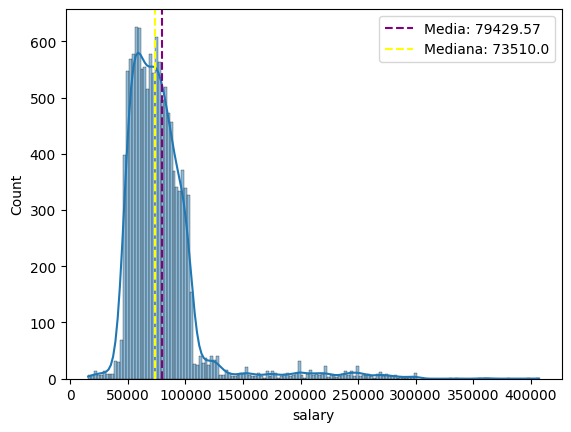

In [581]:
sns.histplot(data=df_clientes_perfil, x="salary", kde=True)

media_salary = round(df_clientes_perfil["salary"].mean(),2)
mediana_salary = df_clientes_perfil["salary"].median()

plt.axvline(media_salary, color = 'purple', linestyle = "--", label = f"Media: {media_salary}")
plt.axvline(mediana_salary, color = 'yellow', linestyle = "--", label = f"Mediana: {mediana_salary}")

plt.legend();



- La distribución de la variable salary muestra que la media y la mediana son prácticamente iguales, lo que indica una distribución bastante equilibrada.

- La mayor concentración de clientes se sitúa en rangos de salario medios (entre 60.000 y 100.000 aproximadamente).

- Se observan algunos valores elevados que podrían considerarse outliers.

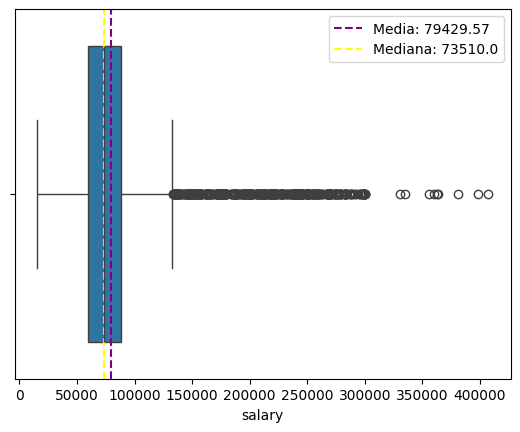

In [582]:
sns.boxplot(data=df_clientes_perfil, x="salary")


plt.axvline(media_salary, color = 'purple', linestyle = "--", label = f"Media: {media_salary}")
plt.axvline(mediana_salary, color = 'yellow', linestyle = "--", label = f"Mediana: {mediana_salary}")

plt.legend();

- El boxplot de la variable salary muestra que la mayor parte de los valores se concentra en un rango aproximado entre 60.000 y 90.000.

- La mediana se sitúa en torno a 79.417, representando el valor central de la distribución.

- Se observa una gran cantidad de valores atípicos (outliers), especialmente en la parte superior, con salarios muy elevados.

- Sesgo hacia la derecha.
- Tengo muchos outli
- Imputaremos por la mediana en este caso.

In [583]:
rango_salary= df_clientes_perfil["salary"].max() - df_clientes_perfil["salary"].min()

coeficiente_variacion_salary = (df_clientes_perfil["salary"].std() / media_salary) * 100

print(rango_salary)
print(coeficiente_variacion_salary)

391619.0
43.72119905000072


- Aqui medimos el salario mas alto del más bajo.
- El Rango del salario es muy grande, por lo cual vemos que la diferencia entre el salario mas bajo y el mas alto, hay mucha diferencia.
- Y confirmamos que existen outliers
- El coeficiente de variacion supera el valor 30 se puede decir que tiene un valor medio-alto.
- Por lo cual la mediana seria la mejor opcion.


- Los valores nulos de salary se han rellenado utilizando la media dentro de cada nivel educativo.

In [584]:
df_clientes_perfil["salary"] = df_clientes_perfil["salary"].fillna(mediana_salary)

In [585]:
df_clientes_perfil.isnull().sum()

loyalty_number            0
country                   0
province                  0
city                      0
postal_code               0
gender                    0
education                 0
salary                    0
marital_status            0
loyalty_card              0
clv                       0
enrollment_type           0
enrollment_year           0
enrollment_month          0
cancellation_year     14670
cancellation_month    14670
cancelled                 0
dtype: int64

In [586]:
df_clientes_perfil.head(5)

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,cancelled
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,<NA>,<NA>,0
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,73510.0,Divorced,Star,3839.61,Standard,2016,3,<NA>,<NA>,0
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,73510.0,Single,Star,3839.75,Standard,2014,7,2018,1,1
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,73510.0,Single,Star,3839.75,Standard,2013,2,<NA>,<NA>,0
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,<NA>,<NA>,0


In [587]:
df_clientes_vuelos["points_accumulated"] = (df_clientes_vuelos["points_accumulated"].round().astype(int))

- Pasamos el dato de float a entero, más, real como puntos.

In [588]:
df_clientes_vuelos.head(5)

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,100018,2017,1,3,0,3,1521,152,0,0
1,100102,2017,1,10,4,14,2030,203,0,0
2,100140,2017,1,6,0,6,1200,120,0,0
3,100214,2017,1,0,0,0,0,0,0,0
4,100272,2017,1,0,0,0,0,0,0,0


In [589]:
col_categoricas_perfil = df_clientes_perfil.select_dtypes(include = "O").columns

col_categoricas_perfil

for col in col_categoricas_perfil:
    print(f"ESTAMOS ANALIZANDO CATEGORIAS DE LA COLUMNA {col}")
    print(df_clientes_perfil[col].unique())
    print("=" * 100)

ESTAMOS ANALIZANDO CATEGORIAS DE LA COLUMNA country
['Canada']
ESTAMOS ANALIZANDO CATEGORIAS DE LA COLUMNA province
['Ontario' 'Alberta' 'British Columbia' 'Quebec' 'Yukon' 'New Brunswick'
 'Manitoba' 'Nova Scotia' 'Saskatchewan' 'Newfoundland'
 'Prince Edward Island']
ESTAMOS ANALIZANDO CATEGORIAS DE LA COLUMNA city
['Toronto' 'Edmonton' 'Vancouver' 'Hull' 'Whitehorse' 'Trenton' 'Montreal'
 'Dawson Creek' 'Quebec City' 'Fredericton' 'Ottawa' 'Tremblant' 'Calgary'
 'Thunder Bay' 'Whistler' 'Peace River' 'Winnipeg' 'Sudbury'
 'West Vancouver' 'Halifax' 'London' 'Regina' 'Kelowna' "St. John's"
 'Victoria' 'Kingston' 'Banff' 'Moncton' 'Charlottetown']
ESTAMOS ANALIZANDO CATEGORIAS DE LA COLUMNA postal_code
['M2Z 4K1' 'T3G 6Y6' 'V6E 3D9' 'P1W 1K4' 'J8Y 3Z5' 'Y2K 6R0' 'P5S 6R4'
 'K8V 4B2' 'H2Y 2W2' 'M8Y 4K8' 'U5I 4F1' 'G1B 3L5' 'H4G 3T4' 'M2M 7K8'
 'M2M 6J7' 'E3B 2H2' 'M1R 4K3' 'T9G 1W3' 'H2Y 4R4' 'V5R 1W3' 'P1L 8X8'
 'K1F 2R2' 'H5Y 2S9' 'V1E 4R6' 'H2T 2J6' 'T3E 2V9' 'H2T 9K8' 'K8T 5M5'
 'V

- Nos analiza las categorias unicas.

## Análisis de variables categóricas

- La columna country no aporta información útil, ya que todos los clientes son de Canada.

- Las columnas province y city sí son interesantes, porque nos permiten ver diferencias entre zonas.

- La columna postal_code tiene demasiados valores distintos, por lo que no es muy útil para analizar.

- Las variables gender, education y marital_status están limpias y bien definidas.

- La columna loyalty_card es importante, ya que permite diferenciar tipos de clientes.

- La columna enrollment_type también es relevante, ya que distingue entre clientes normales y de promoción.

In [590]:
analisis_estadistico(df_clientes_vuelos)

🔹 NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max
loyalty_number,403760.0,549875.383713,258961.514684,100018.0,326699.0,550598.0,772152.0,999986.0
year,403760.0,2017.500352,0.500000,2017.0,2017.0,2018.0,2018.0,2018.0
month,403760.0,6.501335,3.451982,1.0,4.0,7.0,10.0,12.0
flights_booked,403760.0,4.134050,5.230064,0.0,0.0,1.0,8.0,21.0
flights_with_companions,403760.0,1.036569,2.080472,0.0,0.0,0.0,1.0,11.0
total_flights,403760.0,5.170619,6.526858,0.0,0.0,1.0,10.0,32.0
distance,403760.0,1214.460979,1434.098521,0.0,0.0,525.0,2342.0,6293.0
points_accumulated,403760.0,124.263756,146.696401,0.0,0.0,53.0,240.0,676.0
points_redeemed,403760.0,30.838587,125.758002,0.0,0.0,0.0,0.0,876.0
dollar_cost_points_redeemed,403760.0,2.495973,10.172033,0.0,0.0,0.0,0.0,71.0



🔹 CATEGÓRICAS
No hay columnas categóricas en este DataFrame.


,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,100018,2017,1,3,0,3,1521,152,0,0
1,100102,2017,1,10,4,14,2030,203,0,0
2,100140,2017,1,6,0,6,1200,120,0,0
3,100214,2017,1,0,0,0,0,0,0,0
4,100272,2017,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
403755,999902,2018,12,0,0,0,0,0,0,0
403756,999911,2018,12,0,0,0,0,0,0,0
403757,999940,2018,12,3,0,3,1233,123,0,0
403758,999982,2018,12,0,0,0,0,0,0,0


In [591]:
analisis_estadistico(df_clientes_perfil)

🔹 NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max
loyalty_number,16737.0,549735.880445,258912.132453,100018.0,326603.0,550434.0,772019.0,999986.0
salary,16737.0,77923.595447,30096.798629,15609.0,63991.0,73510.0,82940.0,407228.0
clv,16737.0,7988.896536,6860.98228,1898.01,3980.84,5780.18,8940.58,83325.38
enrollment_year,16737.0,2015.253211,1.979111,2012.0,2014.0,2015.0,2017.0,2018.0
enrollment_month,16737.0,6.669116,3.398958,1.0,4.0,7.0,10.0,12.0
cancellation_year,2067.0,2016.503145,1.380743,2013.0,2016.0,2017.0,2018.0,2018.0
cancellation_month,2067.0,6.962748,3.455297,1.0,4.0,7.0,10.0,12.0
cancelled,16737.0,0.123499,0.329019,0.0,0.0,0.0,0.0,1.0



🔹 CATEGÓRICAS


,count,unique,top,freq
country,16737,1,Canada,16737
province,16737,11,Ontario,5404
city,16737,29,Toronto,3351
postal_code,16737,55,V6E 3D9,911
gender,16737,2,Female,8410
education,16737,5,Bachelor,10475
marital_status,16737,3,Married,9735
loyalty_card,16737,3,Star,7637
enrollment_type,16737,2,Standard,15766


,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,cancelled
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,<NA>,<NA>,0
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,73510.0,Divorced,Star,3839.61,Standard,2016,3,<NA>,<NA>,0
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,73510.0,Single,Star,3839.75,Standard,2014,7,2018,1,1
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,73510.0,Single,Star,3839.75,Standard,2013,2,<NA>,<NA>,0
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,<NA>,<NA>,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16732,823768,Canada,British Columbia,Vancouver,V6E 3Z3,Female,College,73510.0,Married,Star,61850.19,Standard,2012,12,<NA>,<NA>,0
16733,680886,Canada,Saskatchewan,Regina,S1J 3C5,Female,Bachelor,89210.0,Married,Star,67907.27,Standard,2014,9,<NA>,<NA>,0
16734,776187,Canada,British Columbia,Vancouver,V5R 1W3,Male,College,73510.0,Single,Star,74228.52,Standard,2014,3,<NA>,<NA>,0
16735,906428,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,73510.0,Married,Star,10018.66,Promotion,2018,4,<NA>,<NA>,0


## Comparación antes y después (df_clientes_perfil)

- Antes, la columna salary tenía muchos valores vacíos. Ahora está completa.

In [592]:
# union dataframes limpios

df_unido = df_clientes_vuelos.merge(df_clientes_perfil,how="inner", on="loyalty_number")

df_unido.shape

(403760, 26)

In [593]:
df_clientes_vuelos.to_csv("data/Customer_Flight_Activity_limpio.csv", index=False)
df_clientes_perfil.to_csv("data/Customer_Loyalty_History_limpio.csv", index=False)
df_unido.to_csv("data/Customer_completo_limpio.csv", index=False)